In [1]:
import pandas as pd
pd.__version__

'2.3.3'

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('default')

In [3]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [5]:
# 9.0. 
churn_data = pd.read_csv('data/churn.csv')
churn_data = churn_data.drop('RowNumber', axis=1)
churn_data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


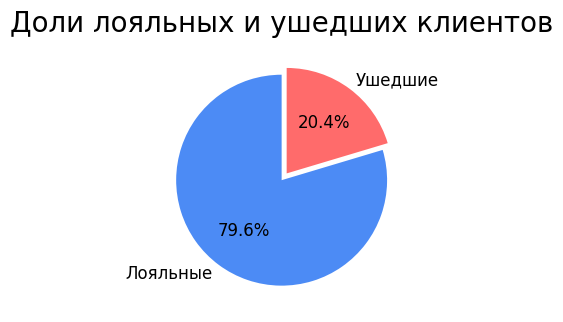

'Данные показывают, что подавляющее большинство клиентов (почти 80%) остаются лояльными банку, в то время как отток составляет 20,4%.'

In [6]:
# 9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.
# подсчитываем количество лояльных и ушедших клиентов
exited_counts = churn_data['Exited'].value_counts()
loyal   = exited_counts.get(0, 0)   # кол-во лояльных клиентов
churned = exited_counts.get(1, 0)   # кол-во ушедших клиентов

# строим график
plt.subplot(1, 2, 2)
plt.pie([loyal, churned],
        labels=[f'Лояльные', f'Ушедшие'],
        colors=['#4c8bf5', '#ff6b6b'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12},
        explode=[0, 0.08]) 

plt.title('Доли лояльных и ушедших клиентов', fontsize=20, pad=12)

plt.tight_layout()
plt.show()

'''Данные показывают, что подавляющее большинство клиентов (почти 80%) остаются лояльными банку, в то время как отток составляет 20,4%.'''

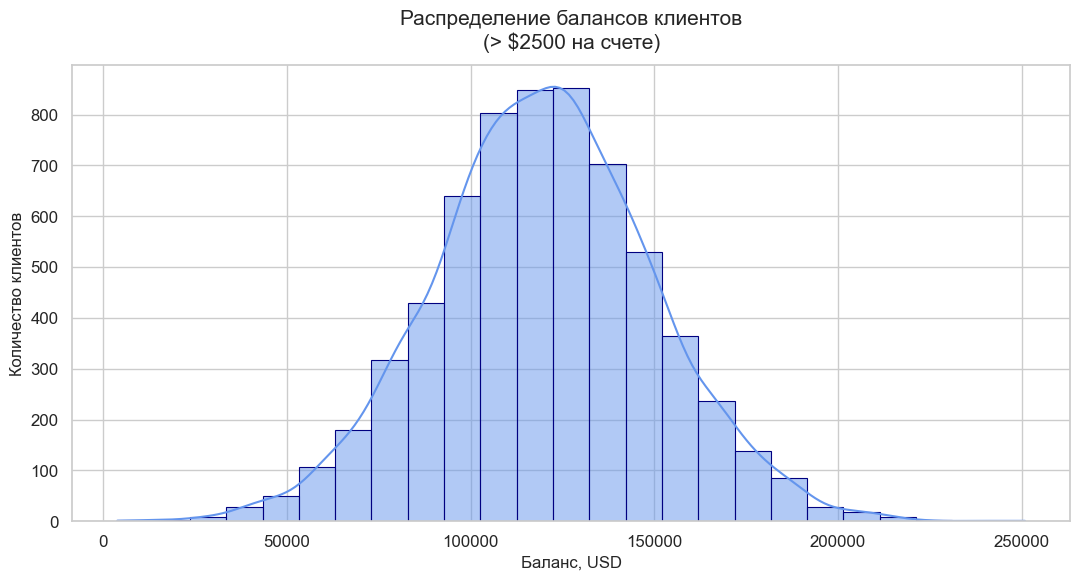

In [8]:
# 9.2 Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.
# фильтруем(выбираем только тех, у кого больше 2,5к на счете)
balances = churn_data[churn_data['Balance'] > 2500]['Balance']

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

plt.figure(figsize=(11, 6))

# Строим график
sns.histplot(
    data=balances,
    bins=25,              
    kde=True,             # кривая плотности
    stat='count',
    color='cornflowerblue',
    edgecolor='navy',
    linewidth=0.8
)

plt.title('Распределение балансов клиентов\n(> $2500 на счете)', fontsize=15, pad=12)
plt.xlabel('Баланс, USD', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)

plt.tight_layout()
plt.show()

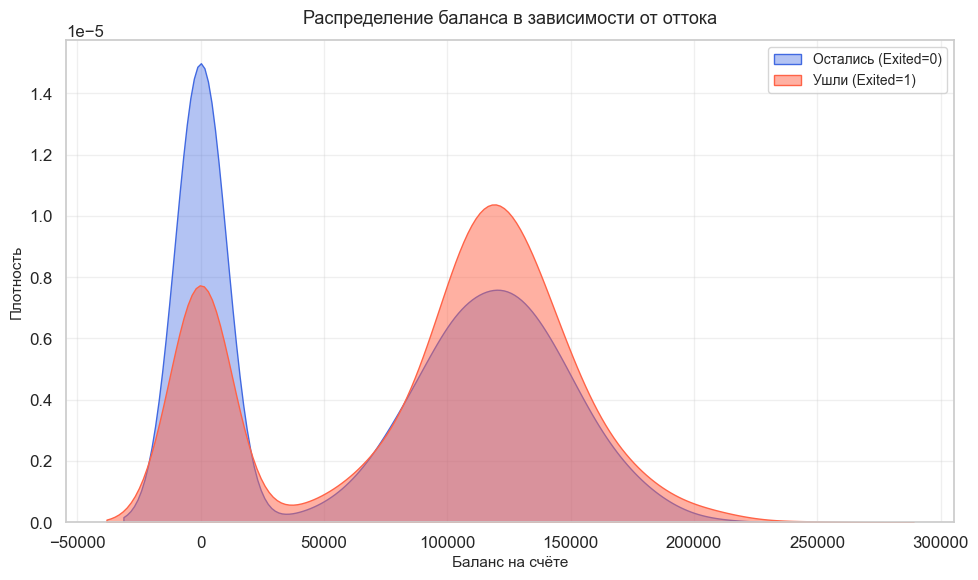

In [9]:
# 9.3.
plt.figure(figsize=(10, 6))
# Создаем отдельные DataFrame для каждой группы
churn_0 = churn_data[churn_data['Exited'] == 0].copy()
churn_1 = churn_data[churn_data['Exited'] == 1].copy()
# Строим графики плотности
sns.kdeplot(data=churn_0, x='Balance', 
            fill=True, color='royalblue', alpha=0.4, label='Остались (Exited=0)')
sns.kdeplot(data=churn_1, x='Balance', 
            fill=True, color='tomato', alpha=0.5, label='Ушли (Exited=1)')
plt.title('Распределение баланса в зависимости от оттока', fontsize=13, pad=12)
plt.xlabel('Баланс на счёте', fontsize=11)
plt.ylabel('Плотность', fontsize=11)  # Исправлено: плотность, а не количество
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

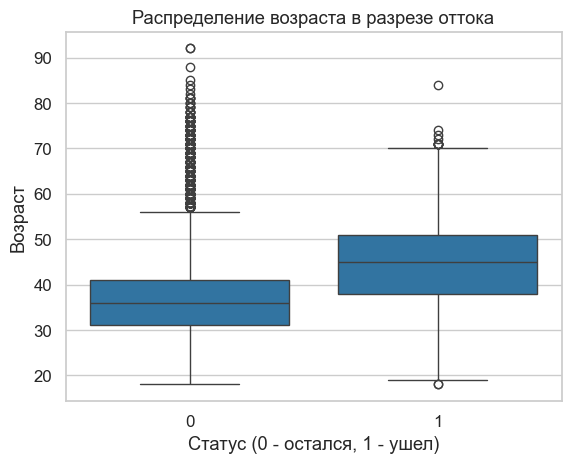

In [10]:
# 9.4.
sns.boxplot(x='Exited', y='Age', data=churn_data)

# Настройка заголовка и меток
plt.title('Распределение возраста в разрезе оттока')
plt.xlabel('Статус (0 - остался, 1 - ушел)')
plt.ylabel('Возраст')

plt.show()

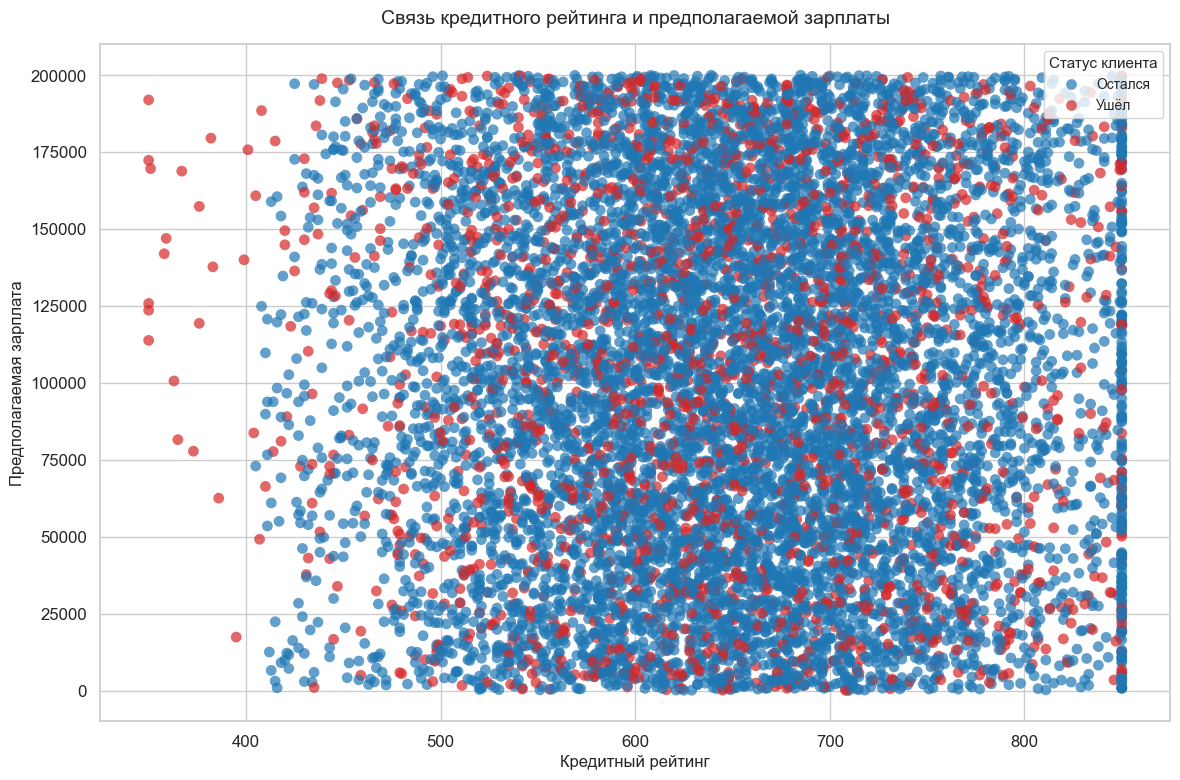

In [11]:
# 9.5.
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=churn_data,
    x='CreditScore',
    y='EstimatedSalary',
    hue='Exited',                   
    palette={0: '#1f77b4', 1: '#d62728'},  # синий — остался, красный — ушёл
    alpha=0.7,                      # прозрачность точек
    s=60,                           # размер точек
    edgecolor='none'                # убираем контур точек
)

# Названия и подписи
plt.title('Связь кредитного рейтинга и предполагаемой зарплаты', fontsize=14, pad=15)
plt.xlabel('Кредитный рейтинг', fontsize=12)
plt.ylabel('Предполагаемая зарплата', fontsize=12)

# Легенда
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ['Остался' if label == '0' else 'Ушёл' for label in labels]
plt.legend(handles, new_labels, title='Статус клиента', 
           loc='upper right', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

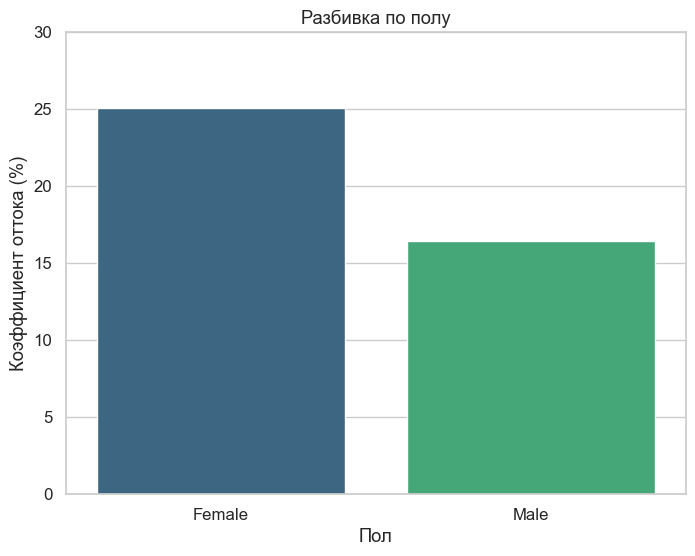

In [12]:
# 9.6.
churn_rate = churn_data.groupby('Gender')['Exited'].mean() * 100
churn_rate = churn_rate.reset_index()
churn_rate.columns = ['Gender', 'Churn Rate (%)']

plt.figure(figsize=(8, 6))
sns.barplot(x='Gender', y='Churn Rate (%)', hue='Gender', data=churn_rate, palette='viridis', legend=False)
plt.title('Разбивка по полу')
plt.ylabel('Коэффициент оттока (%)')
plt.xlabel('Пол')
plt.ylim(0, 30) 
plt.show()

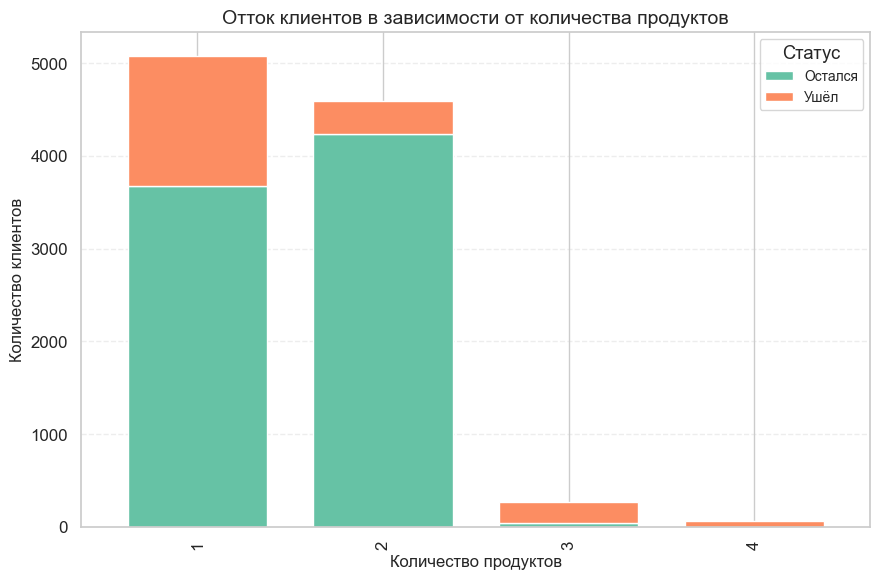

In [18]:
# 9.7.
pivot = churn_data.pivot_table(
    index='NumOfProducts',
    columns='Exited',
    values='CustomerId',
    aggfunc='count',
    fill_value=0
)

pivot.columns = ['Остался', 'Ушёл']

colors = ['#66c2a5', '#fc8d62']

fig, ax = plt.subplots(figsize=(9, 6))

pivot.plot(
    kind='bar',
    stacked=True,
    color=colors,
    ax=ax,
    width=0.75
)

ax.set_title('Отток клиентов в зависимости от количества продуктов', fontsize=14)
ax.set_xlabel('Количество продуктов', fontsize=12)
ax.set_ylabel('Количество клиентов', fontsize=12)

ax.legend(title='Статус', loc='upper right', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

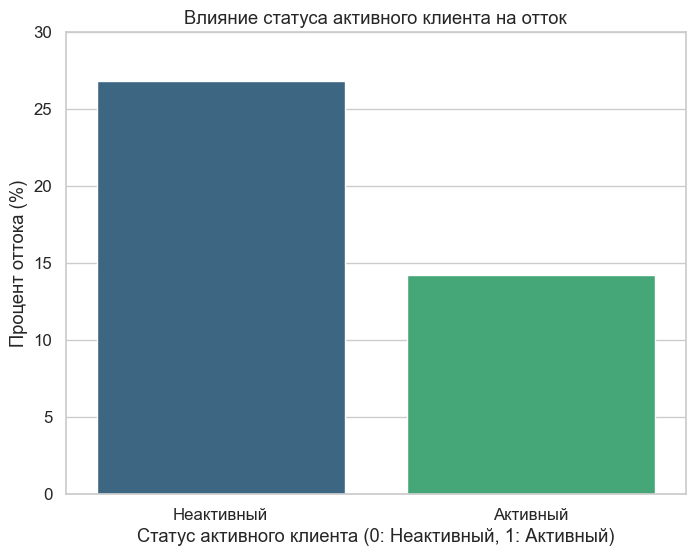

In [21]:
# 9.8.
churn_rate = churn_data.groupby('IsActiveMember')['Exited'].mean() * 100

plt.figure(figsize=(8, 6)) 
sns.barplot(x=churn_rate.index, hue=churn_rate.index, y=churn_rate.values, palette='viridis', legend=False)
plt.xlabel('Статус активного клиента (0: Неактивный, 1: Активный)')
plt.ylabel('Процент оттока (%)')
plt.title('Влияние статуса активного клиента на отток')
plt.xticks([0, 1], ['Неактивный', 'Активный']) 
plt.ylim(0, 30)  
plt.show()

In [24]:
# 9.9.
import plotly.express as px

churn_rate = churn_data.groupby('Geography')['Exited'].mean().reset_index()
churn_rate['Churn_Rate_%'] = churn_rate['Exited'] * 100
churn_rate = churn_rate.rename(columns={'Geography': 'country'})



country_iso = {
    'France':  'FRA',
    'Germany': 'DEU',
    'Spain':   'ESP'
}

churn_rate['iso_alpha'] = churn_rate['country'].map(country_iso)

# Строим карту
fig = px.choropleth(
    churn_rate,
    locations='iso_alpha',              
    color='Churn_Rate_%',               
    hover_name='country',               
    color_continuous_scale='RdYlBu_r',  
    range_color=(0, 35),                # фиксируем масштаб (можно подстроить)
    title='Доля ушедших клиентов по странам (Churn Rate %)',
    labels={'Churn_Rate_%': 'Churn rate (%)'},
    projection='natural earth',         # красивый проекция
    template='plotly_white'
)

# Внешний вид
fig.update_geos(
    showframe=False,
    showcoastlines=True,
    coastlinecolor='lightgray',
    showland=True,
    landcolor='lightgray',   
    showocean=True,
    oceancolor='white'
)

fig.update_layout(
    title_font_size=22,
    title_x=0.5,
    coloraxis_colorbar=dict(
        title='Churn rate (%)',
        thickness=20,
        len=0.7,
        yanchor='middle',
        y=0.5,
        xanchor='right',
        x=1.05
    ),
    margin=dict(l=0, r=0, t=60, b=0),
    height=600
)

fig.show()

fig.write_html('geography.html')

Tenure,0,1,2,3,4,5,6,7,8,9,10
CreditScoreCat,,,,,,,,,,,
Excellent,0.275000,0.208333,0.137255,0.168317,0.131868,0.233333,0.241379,0.127660,0.196078,0.270833,0.254902
Fair,0.217391,0.215596,0.213043,0.216450,0.197248,0.206897,0.236364,0.171103,0.209016,0.190045,0.205357
Good,0.203822,0.203608,0.187342,0.205962,0.195122,0.214470,0.182857,0.191892,0.152355,0.194667,0.197802
Poor,0.226415,0.259398,0.211765,0.212245,0.233202,0.199153,0.179916,0.151261,0.214575,0.251082,0.169492
Very_Poor,0.444444,0.253731,0.151515,0.285714,0.293103,0.149254,0.225352,0.206349,0.253521,0.229508,0.333333


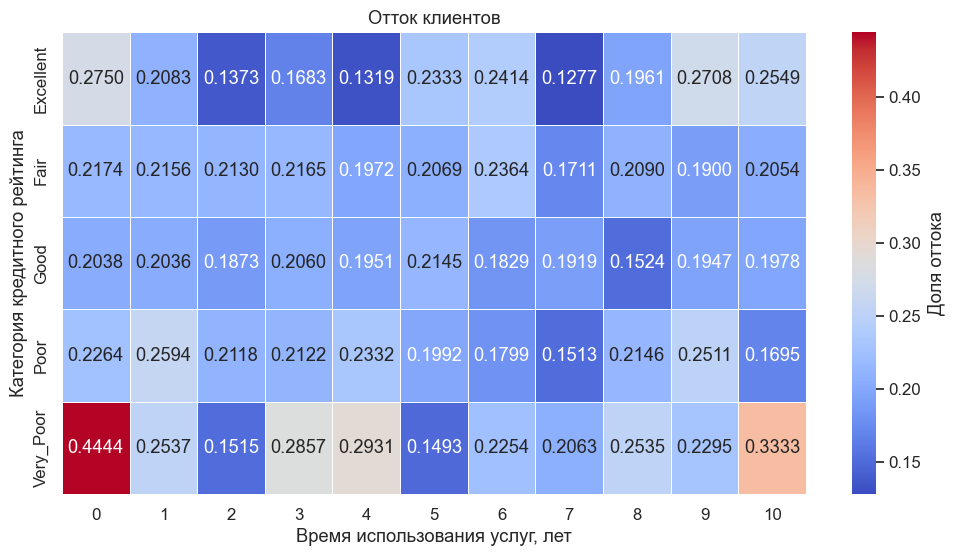

In [30]:
# 9.10. 
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

churn_data['CreditScoreCat'] = churn_data['CreditScore'].apply(get_credit_score_cat)

# Создание сводной таблицы
pivot = churn_data.pivot_table(values='Exited', index='CreditScoreCat', columns='Tenure', aggfunc='mean')
display(pivot)

# Построение тепловой карты
plt.figure(figsize=(12, 6))  
sns.heatmap(
    pivot, 
    annot=True,  
    fmt=".4f",   
    cmap='coolwarm',  
    linewidths=0.5,  
    cbar_kws={'label': 'Доля оттока'}  
)

plt.title('Отток клиентов')  
plt.xlabel('Время использования услуг, лет')  
plt.ylabel('Категория кредитного рейтинга')  
plt.show()  